In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x2180a17ded0>)

In [3]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [4]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


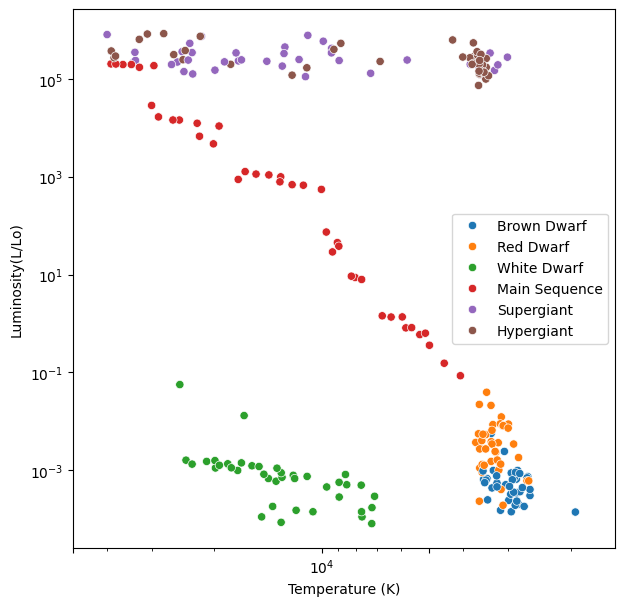

In [6]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [8]:
from sklearn.decomposition import PCA
data = df_stars.drop(columns=["Star color", "Star type", "Spectral Class"])
X = np.array(data)
n_components=2

pca = PCA(n_components=2) # n_components can be optionally set
pca.fit(X) 

data_transformed = pca.fit_transform(X)
mean = pca.mean_ # length 10 mean of the data
components = pca.components_ # 4x10 matrix of components, multiply each by respective eigenvalue to reconstruct

# Reconstruction of object1
# Xreconstruct[0] = mean + eigenvectors*eigenvalues[0]

print(data_transformed.shape)
print(components.shape)


(240, 2)
(2, 4)


In [9]:
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]


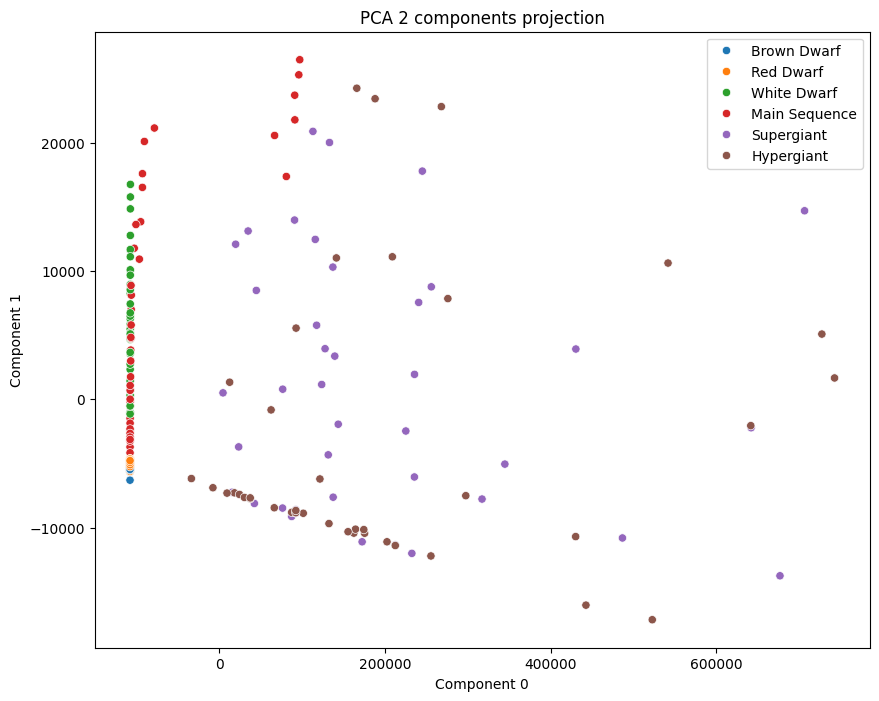

In [19]:
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_transformed[:,0], y=data_transformed[:,1], hue=labels)
plt.title("PCA 2 components projection")
plt.xlabel("Component 0")
plt.ylabel("Component 1")
plt.show()

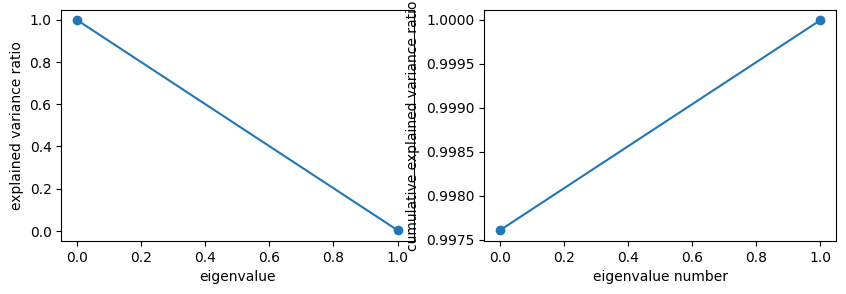

In [12]:
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)

ax.plot(np.arange(n_components), evals)
ax.scatter(np.arange(n_components), evals)

ax.set_xlabel("eigenvalue")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(n_components), evals.cumsum())
ax.scatter(np.arange(n_components), evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

In [13]:
X_back  = pca.inverse_transform(data_transformed)

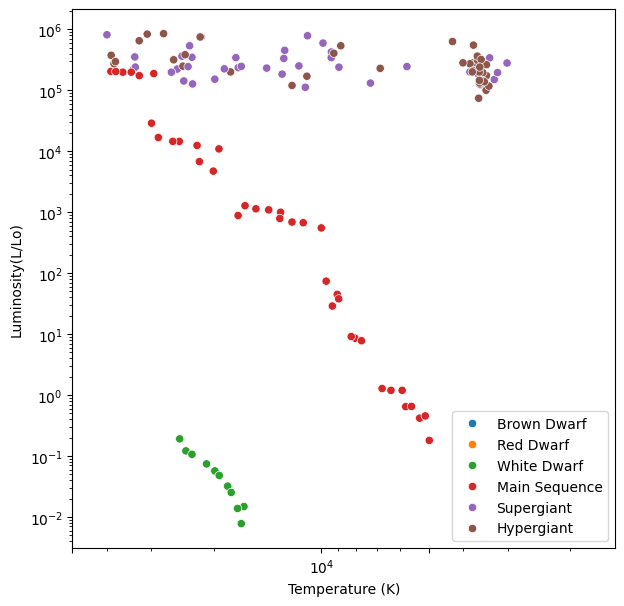

In [14]:
df_new = df_stars
df_new['Temperature (K)'] = X_back[:,0]
df_new['Luminosity(L/Lo)'] = X_back[:,1]
df_new['Radius(R/Ro)'] = X_back[:,2]
df_new['Absolute magnitude(Mv)'] = X_back[:,3]
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_new, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

### Apply standardization

Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784]


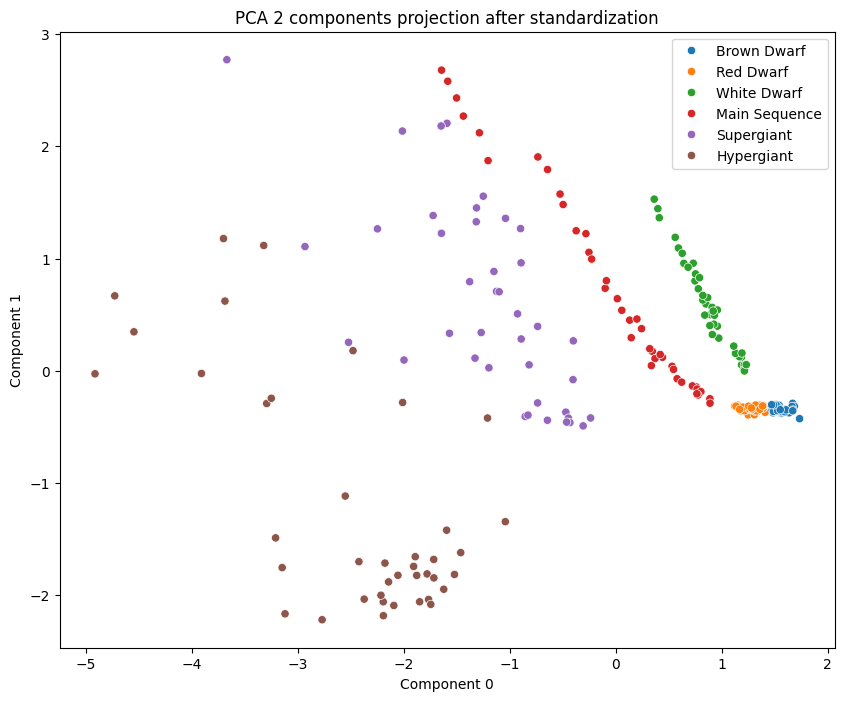

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(data)

pca = PCA(n_components=2)
data_trasformed_stand = pca.fit_transform(X)
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_trasformed_stand[:,0], y=data_trasformed_stand[:,1], hue=labels)
plt.xlabel("Component 0")
plt.ylabel("Component 1")

plt.title("PCA 2 components projection after standardization")
plt.show()


Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784 0.09329645 0.0681218 ]


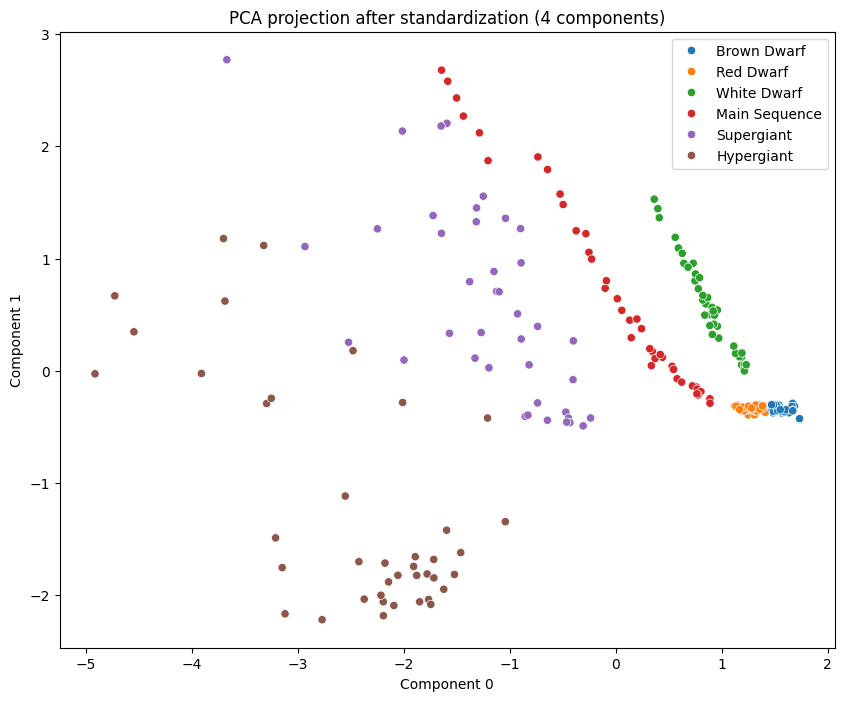

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(data)

pca = PCA()
data_trasformed_stand = pca.fit_transform(X)
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))
fig = plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_trasformed_stand[:,0], y=data_trasformed_stand[:,1], hue=labels)
plt.xlabel("Component 0")
plt.ylabel("Component 1")

plt.title("PCA projection after standardization (4 components)")
plt.show()


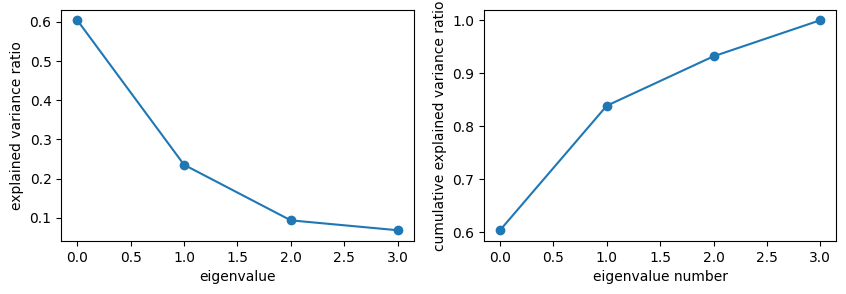

In [25]:
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)
n_components=4
ax.plot(np.arange(n_components), evals)
ax.scatter(np.arange(n_components), evals)

ax.set_xlabel("eigenvalue")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(n_components), evals.cumsum())
ax.scatter(np.arange(n_components), evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()